In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 300
})

In [27]:
models = ["AutoEncoder", "Autoformer", "DLinear", "FEDformer", "TimesNet", "Transformer"]
file_names = [f"../results/FHP_{name}" for name in models]

auc_pr_scores = {model: [] for model in models}

for model, file_name in zip(models,file_names):
    df = pd.read_csv(f"{file_name}.csv")
    df = df[df['params_strategy'] == 'overlapping']
    df = df.dropna(subset=['value'])
    auc_pr_scores[model] = df['value'].tolist()
    print(f"Loaded {len(auc_pr_scores[model])} AUC-PR scores for {model}.")

model_medians = {m: (np.median(auc_pr_scores[m]) if len(auc_pr_scores[m])>0 else -np.inf) for m in models}

hex_colors = [
    "#F94144",
    "#F3722C",
    "#F8961E",
    "#F9C74F",
    "#90BE6D",
    "#43AA8B",
    "#577590",
]

# Create a simple color mapping for models
model_colors = {model: hex_colors[i % len(hex_colors)+1] for i, model in enumerate(models)}

models = sorted(models, key=lambda m: model_medians[m], reverse=True)

Loaded 54 AUC-PR scores for AutoEncoder.
Loaded 56 AUC-PR scores for Autoformer.
Loaded 54 AUC-PR scores for DLinear.
Loaded 54 AUC-PR scores for FEDformer.
Loaded 54 AUC-PR scores for TimesNet.
Loaded 54 AUC-PR scores for Transformer.


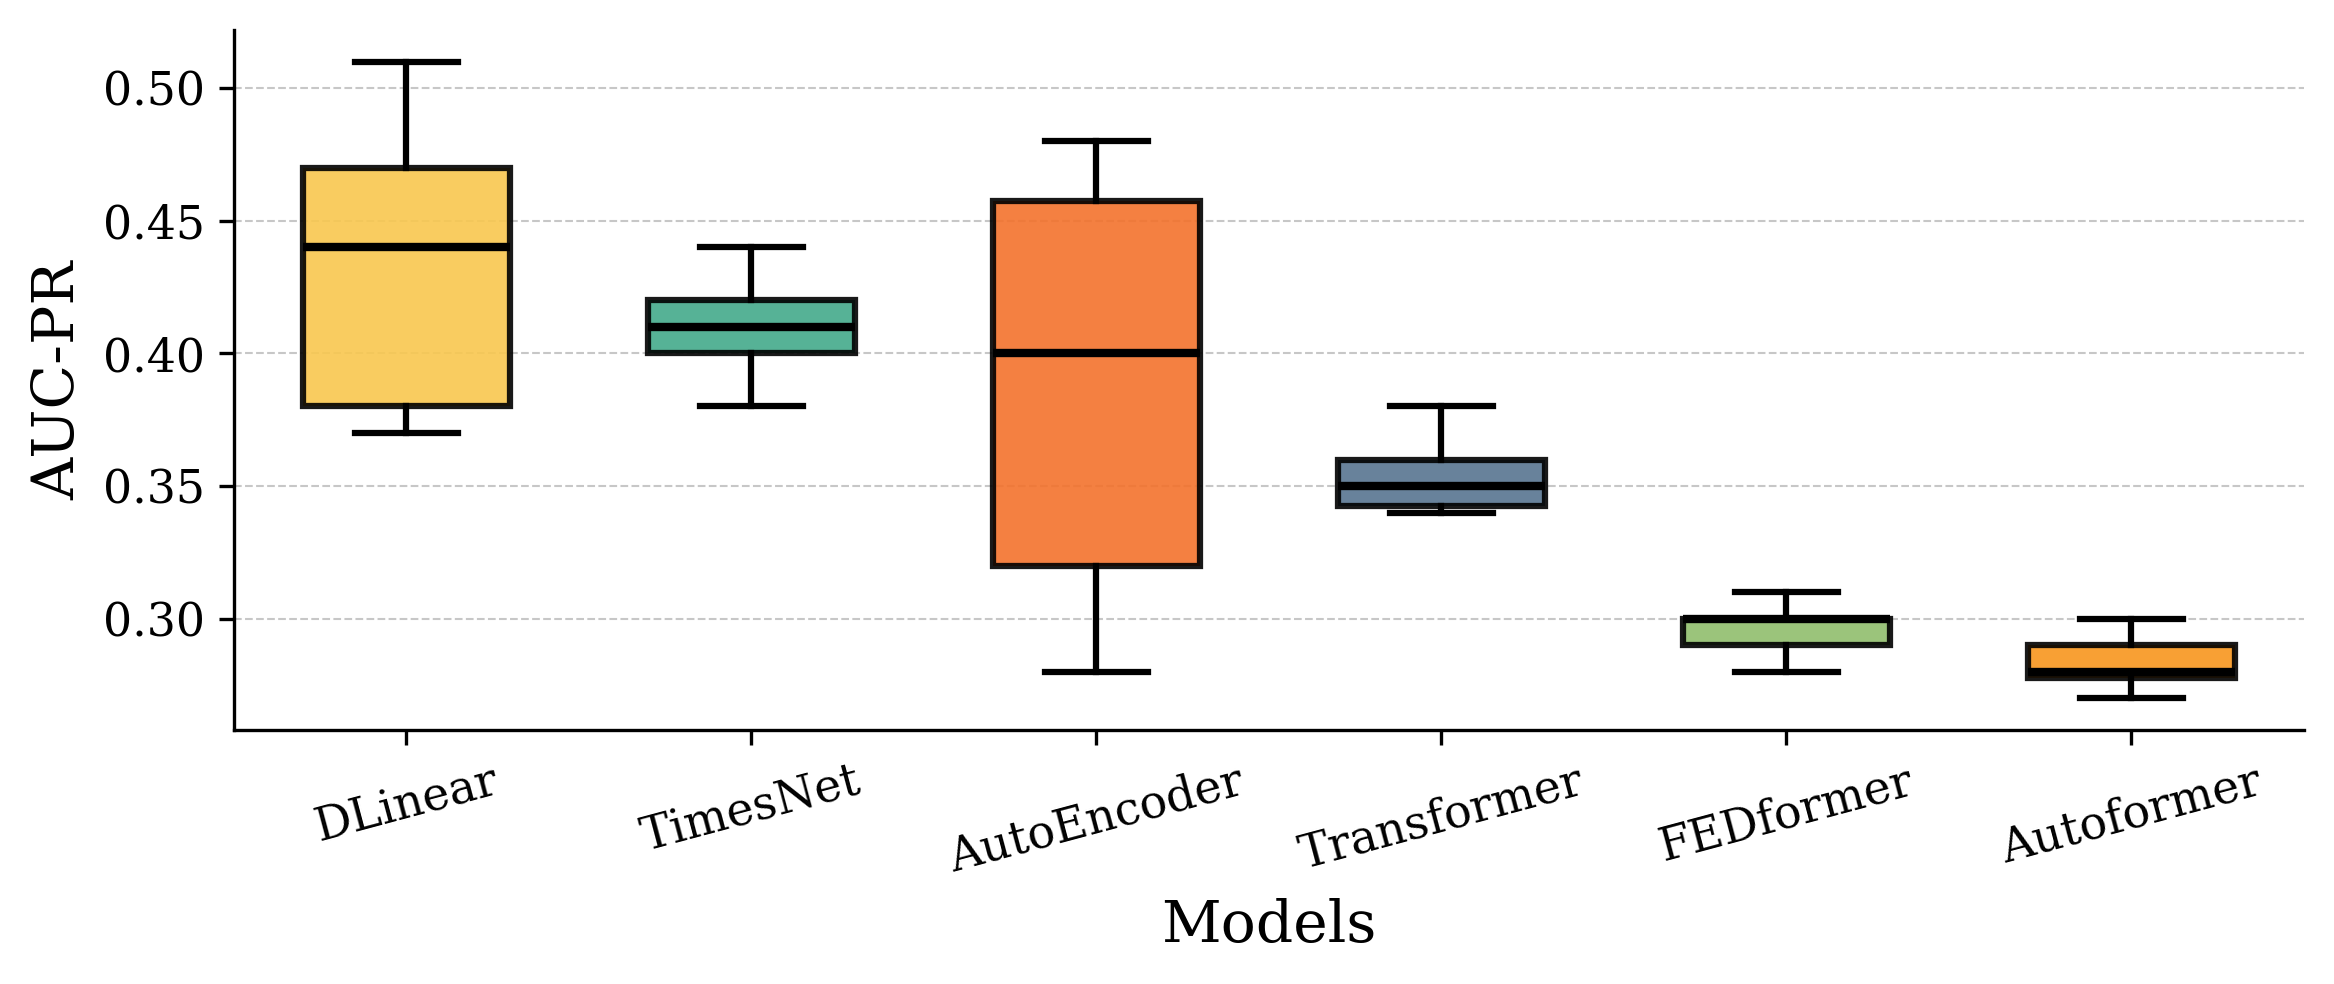

In [28]:
plt.figure(figsize=(8, 3.5))

bp = plt.boxplot(
    [auc_pr_scores[model] for model in models],
    tick_labels=models,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
    medianprops=dict(color='black', linewidth=2),
    boxprops=dict(linewidth=1.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)

for patch, model in zip(bp['boxes'], models):
    patch.set_facecolor(model_colors[model])
    patch.set_alpha(0.90)

plt.ylabel('AUC-PR')
plt.xlabel('Models')

# Optional for TKDE:
# titles are often omitted in final figures
# plt.title('AUC-PR Scores by Model')

plt.grid(
    True,
    which="major",
    axis='y',
    linestyle="--",
    linewidth=0.5,
    alpha=0.7
)

plt.xticks(rotation=15)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../Figures/auc_pr_comparison.pdf', bbox_inches='tight')
plt.show()

In [29]:
df_robust = pd.read_csv("../results/robust_AutoEncoder.csv")
values = df_robust['value'].dropna().tolist()

count_above_037 = sum(v > 0.37 for v in values)
count_below_037 = sum(v < 0.37 for v in values)
count_equal_037 = sum(v == 0.37 for v in values)
print(f"Count of AUC-PR > 0.37: {count_above_037}")
print(f"Count of AUC-PR < 0.37: {count_below_037}")
print(f"Count of AUC-PR = 0.37: {count_equal_037}")

Count of AUC-PR > 0.37: 33
Count of AUC-PR < 0.37: 16
Count of AUC-PR = 0.37: 5


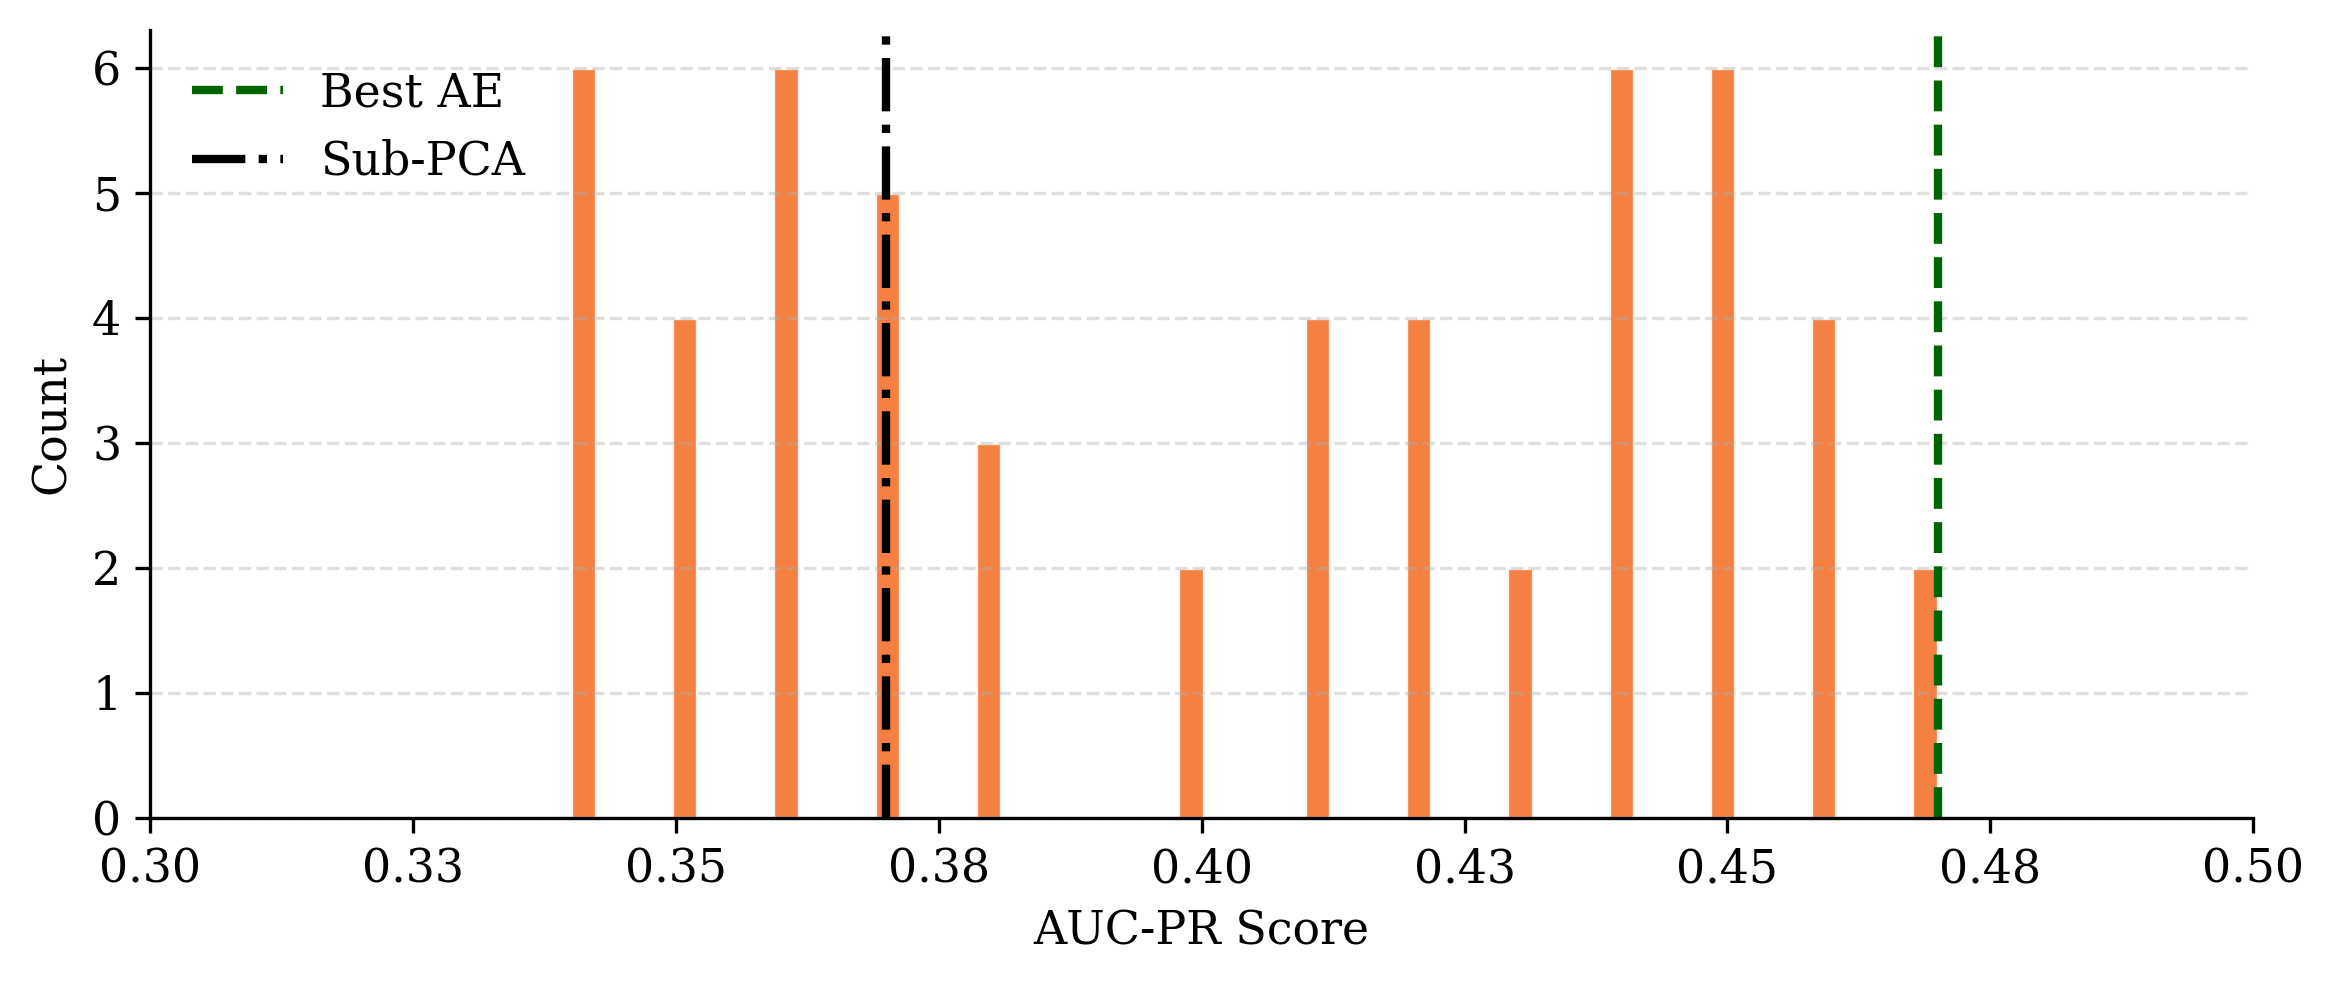

In [30]:
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.hist(
    values,
    bins=54,
    color=model_colors["AutoEncoder"],
    edgecolor='white',
    linewidth=0.8,
    alpha=0.9,

)

# best ae
ax.axvline(
    0.47,
    color='darkgreen',
    linestyle='--',
    linewidth=2,
    label='Best AE'
)
# sub-pca baseline
ax.axvline(
    0.37,
    color="black",
    linestyle='-.',
    linewidth=2,
    label='Sub-PCA'
)

ax.set_xlabel('AUC-PR Score', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_xlim(0.3, 0.5)

ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('../Figures/auc_pr_distribution_ae.pdf', bbox_inches='tight')
plt.show()